<a href="https://colab.research.google.com/github/clarkfavour5-arch/Google-colab/blob/main/Clarkfavour.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Libraries Imported
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
# Load Dataset
df = pd.read_csv("clark.csv")
print(df.head()) # or df.head()

   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  


In [ ]:
# Checking the values that are missing
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [ ]:
# Filling the missing Age Value with Age median
df['Age'].fillna(df['Age'].median(), inplace=True)
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


/tmp/ipykernel_43992/796222500.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [ ]:
# Filling the missing Fare Value with Fare median
df['Fare'].fillna(df['Fare'].median(), inplace=True)
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64


/tmp/ipykernel_43992/17639129.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Fare'].fillna(df['Fare'].median(), inplace=True)


In [ ]:
# Step 3d: Dropping the Cabin column because it has too many missing values
df.drop(columns=['Cabin'], inplace=True)
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
# Dropping the rows with any missing Embarked
df.dropna(subset=['Embarked'], inplace=True)
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
# Creating a new variable called sizeOfFamily
df['sizeOfFamily'] = df['SibSp'] + df['Parch'] + 1

In [ ]:
# Convert categorical variables (Sex and Embarked) to numeric
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

/tmp/ipykernel_43992/367986552.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set1')


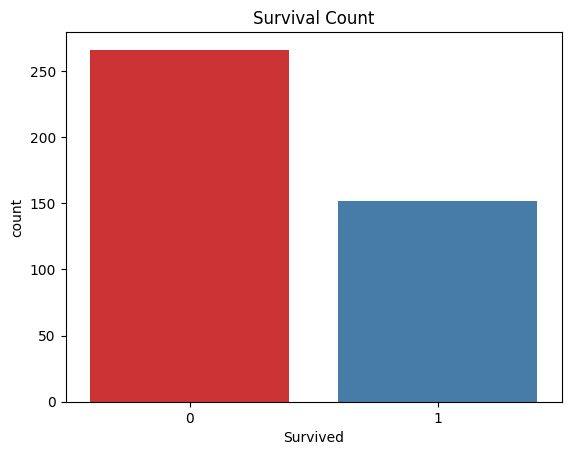

In [ ]:
# Checking the Survival Count
sns.countplot(x='Survived', data=df, palette='Set1')
plt.title("Survival Count")
plt.show()

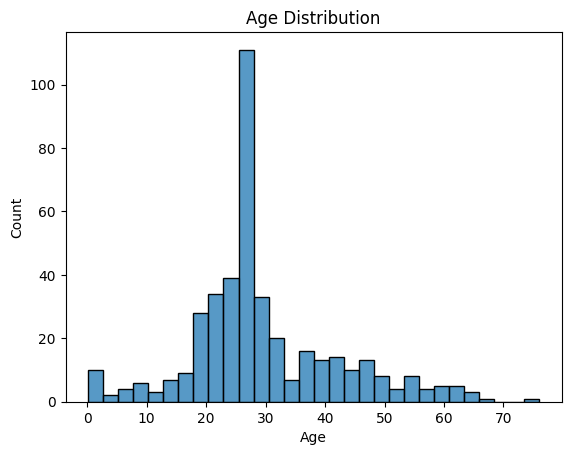

In [ ]:
# Step 5c: Age Distribution
sns.histplot(df['Age'], bins=30)
plt.title("Age Distribution")
plt.show()

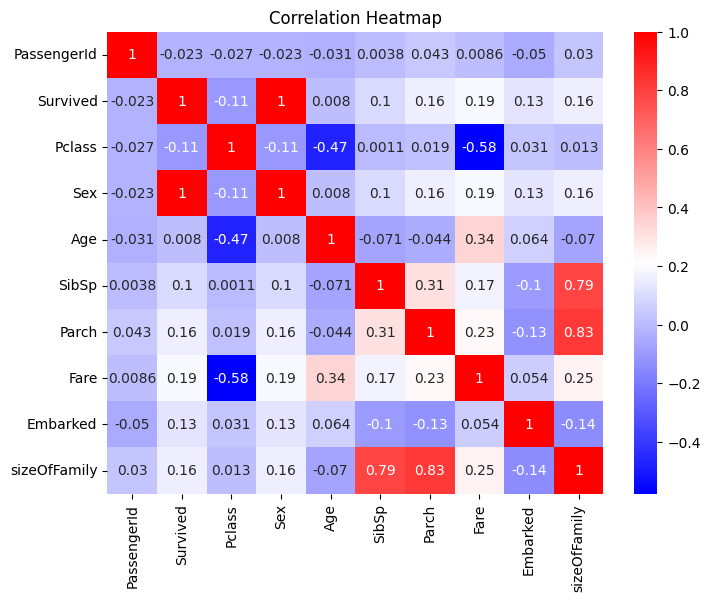

In [ ]:
# Step 5d: Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), cmap='bwr', annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Select Features and Target
X = df[['Age', 'Sex', 'Pclass', 'Fare', 'sizeOfFamily']]
y = df['Survived']

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Build Logistic Regression Model
logRegmodel = LogisticRegression(max_iter=200)
logRegmodel.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [ ]:
# Make Predictions
y_pred = logRegmodel.predict(X_test)

In [ ]:
# Accuracy
accuracyValue = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracyValue)

Accuracy: 1.0


In [ ]:
# Confusion Matrix
cmVal = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cmVal)

Confusion Matrix:
 [[50  0]
 [ 0 34]]


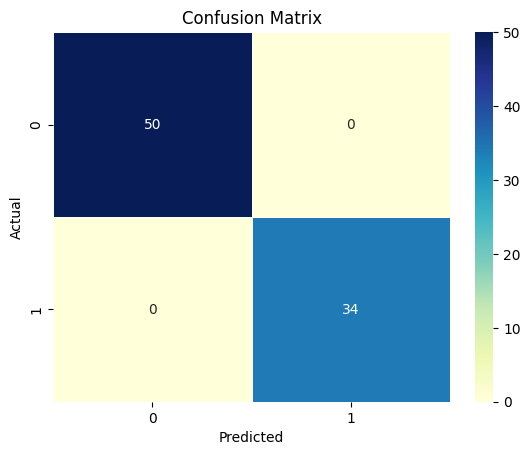

In [ ]:
# Plot Confusion Matrix
sns.heatmap(data=cmVal, cmap = "YlGnBu", annot = True, fmt = "d", linewidths = 0.5)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()